<a href="https://colab.research.google.com/github/Sagnik-Chowdhury/Federated-Learning-1/blob/Sourit/Scaffolding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SCAFFOLD Optimization & Statistical Privacy


## Advanced Drift Correction using Control Variates

**Objective:**
While FedProx addresses client drift via a proximal penalty, **SCAFFOLD** (Stochastic Controlled Averaging) attempts to correct this drift directly within the gradient descent step using mathematical Control Variates.

**The Mechanism:**
1. The server maintains a global control variate representing the overarching direction of the model.
2. Each client maintains a local control variate representing their specific data bias.
3. During local training, clients modify their gradients based on the difference between these variates, physically steering the optimizer away from local bias.

**The Hypothesis:**
Because SCAFFOLD is highly aggressive at correcting variance, we expect it to struggle when external statistical noise is injected. The mathematical corrections may compound the noise rather than filter it.


## Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, TensorDataset
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
import copy
import pandas as pd
import matplotlib.pyplot as plt

## Architecture

In [2]:
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        return self.fc4(x)

In [3]:
class TabularNet(nn.Module):
    def __init__(self):
        super(TabularNet, self).__init__()
        # Reduced capacity: 30 -> 16 -> 8 -> 2
        self.fc1 = nn.Linear(30, 16)
        # Dropout randomly turns off 20% of neurons to prevent memorization
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x) # Apply dropout after the first layer
        x = self.relu(self.fc2(x))
        return self.fc3(x)

## Data Preparation

In [4]:
NUM_CLIENTS = 20

In [5]:
print("Preparing MNIST Dataset (Integrated Data)")

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

mnist_full = datasets.MNIST('./data', train=True, download=True, transform=transform)
mnist_split = random_split(mnist_full, [len(mnist_full) // NUM_CLIENTS] * NUM_CLIENTS)
mnist_loaders = [DataLoader(ds, batch_size=32, shuffle=True) for ds in mnist_split]

mnist_test = datasets.MNIST('./data', train=False, download=True, transform=transform)
mnist_test_loader = DataLoader(mnist_test, batch_size=1000, shuffle=False)

print("\nData preparation complete")

Preparing MNIST Dataset (Integrated Data)


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 486kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.13MB/s]


Data preparation complete


In [6]:
from sklearn.model_selection import train_test_split

print("Preparing Breast Cancer Dataset (Strict Train/Test Split)")

# 1. Load and scale the data
data = load_breast_cancer()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data.data)
y = data.target

# 2. THE FIX: Strictly separate 20% of the data for testing BEFORE tensor conversion
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Convert to PyTorch Tensors
tabular_train = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
tabular_test = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

# 4. Split ONLY the training data among clients
tab_split_size = len(tabular_train) // NUM_CLIENTS
tab_splits = [tab_split_size] * NUM_CLIENTS
tab_splits[-1] += len(tabular_train) % NUM_CLIENTS
tabular_loaders = [DataLoader(ds, batch_size=8, shuffle=True) for ds in random_split(tabular_train, tab_splits)]

# 5. The Test Loader now holds data the clients have NEVER seen
tabular_test_loader = DataLoader(tabular_test, batch_size=len(tabular_test), shuffle=False)

print("\nData preparation complete")

Preparing Breast Cancer Dataset (Strict Train/Test Split)

Data preparation complete


## The Defense Mechanism: SCAFFOLD Aggregation & Control Variates

Unlike standard aggregation methods that only average model weights, SCAFFOLD requires a dual-aggregation system.

**How it works:**
1. **Weight Aggregation:** The server averages the client weights exactly like standard FedAvg.

2. **Control Variate Aggregation:** The server collects the "drift deltas" ($\Delta c_i$) from every client. It averages these deltas and adds them to the **Global Control Variate** ($c$).

This global control variate essentially acts as a map of the true objective. In the next round, the server broadcasts this updated map back to the clients so they can correct their local gradients before they step off course.

In [7]:
def scaffold_aggregation(client_weights_list, control_deltas_list, global_control):
    """
    SCAFFOLD requires the server to aggregate TWO things:
    1. The standard model weights.
    2. The control variate deltas (to update the global drift map).
    """
    # 1. Aggregate Weights (Standard FedAvg)
    avg_weights = copy.deepcopy(client_weights_list[0])
    for key in avg_weights.keys():
        stacked_weights = torch.stack([client[key] for client in client_weights_list])
        avg_weights[key] = torch.mean(stacked_weights, dim=0)

    # 2. Aggregate Control Variates: c = c + (1/N) * sum(delta c_i)
    updated_global_control = copy.deepcopy(global_control)
    for name in updated_global_control.keys():
        stacked_deltas = torch.stack([delta[name] for delta in control_deltas_list])
        updated_global_control[name] += torch.mean(stacked_deltas, dim=0)

    return avg_weights, updated_global_control

In [8]:
def add_dp_noise(weights, noise_type='none', scale=0.01):
    """Injects Differential Privacy noise into the aggregated weights."""
    if noise_type == 'none':
        return weights
    noisy_weights = copy.deepcopy(weights)
    for key in noisy_weights.keys():
        tensor = noisy_weights[key]
        if noise_type == 'normal':
            noise = torch.randn_like(tensor) * scale
        elif noise_type == 'laplace':
            m = torch.distributions.laplace.Laplace(torch.tensor([0.0]), torch.tensor([scale]))
            noise = m.sample(tensor.shape).squeeze(-1).to(tensor.device)
        noisy_weights[key] = tensor + noise
    return noisy_weights

## Automated Grid Search Execution (SCAFFOLD)

This loop executes the SCAFFOLD training phase across our two data modalities.

During local training, each client utilizes its own **Local Control Variate** ($c_i$) alongside the global one ($c$) to physically alter the PyTorch gradients ($g = g - c_i + c$).

* **Federated Rounds:** 5
* **DP Noise Scale:** 0.05
* **Noise Types:** Baseline (None), Gaussian (Normal), Laplace

In [9]:
datasets_to_test = ['mnist', 'tabular']
noise_types_to_test = ['none', 'normal', 'laplace']
NOISE_SCALE = 0.05
federated_rounds = 5
epochs_per_round = 1

experiment_results = {'mnist': {}, 'tabular': {}}
history = {
    'mnist': {n: {'test_acc': [], 'test_loss': [], 'train_loss': []} for n in noise_types_to_test},
    'tabular': {n: {'test_acc': [], 'test_loss': [], 'train_loss': []} for n in noise_types_to_test}
}

criterion_eval = nn.CrossEntropyLoss()

In [10]:
for dataset in datasets_to_test:
    print(f"\nTESTING DATASET: {dataset.upper()}")

    for noise in noise_types_to_test:
        print(f"\n[{noise.upper()} NOISE]")

        if dataset == 'mnist':
            global_model = MNISTNet()
            loaders = mnist_loaders
            test_loader = mnist_test_loader
            lr = 0.001
        else:
            global_model = TabularNet()
            loaders = tabular_loaders
            test_loader = tabular_test_loader
            lr = 0.01

        # Initialize SCAFFOLD Controls specific to this dataset's architecture
        global_control = {key: torch.zeros_like(val) for key, val in global_model.state_dict().items()}
        client_controls = [{key: torch.zeros_like(val) for key, val in global_model.state_dict().items()} for _ in range(NUM_CLIENTS)]

        for round_num in range(federated_rounds):
            client_weights = []
            control_deltas_list = []

            for client_idx in range(NUM_CLIENTS):
                local_model = MNISTNet() if dataset == 'mnist' else TabularNet()
                local_model.load_state_dict(global_model.state_dict())

                optimizer = optim.Adam(local_model.parameters(), lr=lr)
                criterion = nn.CrossEntropyLoss()

                local_model.train()
                num_steps = 0
                for epoch in range(epochs_per_round):
                    for inputs, labels in loaders[client_idx]:
                        optimizer.zero_grad()
                        outputs = local_model(inputs)
                        loss = criterion(outputs, labels)
                        loss.backward()

                        # Apply Control Variates to the Gradients during training
                        with torch.no_grad():
                            for name, param in local_model.named_parameters():
                                if param.grad is not None:
                                    server_c = global_control[name]
                                    local_c = client_controls[client_idx][name]
                                    param.grad.data += (server_c - local_c)

                        optimizer.step()
                        num_steps += 1

                # Calculate Control Variate Deltas for your scaffold_aggregation function
                control_delta = {}
                with torch.no_grad():
                    for key in global_model.state_dict().keys():
                        global_w = global_model.state_dict()[key]
                        local_w = local_model.state_dict()[key]

                        c_old = client_controls[client_idx][key]
                        c_global = global_control[key]

                        # Math: c_new = c_old - c_global + (global_w - local_w) / (K * lr)
                        c_new = c_old - c_global + (global_w - local_w) / (num_steps * lr)

                        control_delta[key] = c_new - c_old
                        client_controls[client_idx][key] = c_new # Update local memory

                client_weights.append(local_model.state_dict())
                control_deltas_list.append(control_delta)

            # Server Aggregation (Using your exact 2-part SCAFFOLD function)
            aggregated_weights, global_control = scaffold_aggregation(client_weights, control_deltas_list, global_control)

            # Statistical Noise Injection
            secured_weights = add_dp_noise(aggregated_weights, noise_type=noise, scale=NOISE_SCALE)
            global_model.load_state_dict(secured_weights)

            # --- ROUND EVALUATION ---
            global_model.eval()

            train_loss_accum, train_total = 0.0, 0
            with torch.no_grad():
                for client_loader in loaders:
                    for inputs, labels in client_loader:
                        outputs = global_model(inputs)
                        train_loss_accum += criterion_eval(outputs, labels).item() * inputs.size(0)
                        train_total += labels.size(0)
            avg_train_loss = train_loss_accum / train_total

            correct, test_total, test_loss_accum = 0, 0, 0.0
            with torch.no_grad():
                for inputs, labels in test_loader:
                    outputs = global_model(inputs)
                    test_loss_accum += criterion_eval(outputs, labels).item() * inputs.size(0)
                    _, predicted = torch.max(outputs.data, 1)
                    test_total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            acc = 100 * correct / test_total
            avg_test_loss = test_loss_accum / test_total

            history[dataset][noise]['test_acc'].append(acc)
            history[dataset][noise]['test_loss'].append(avg_test_loss)
            history[dataset][noise]['train_loss'].append(avg_train_loss)
            print(f"   Round {round_num+1} | Acc: {acc:.2f}% | Test Loss: {avg_test_loss:.4f} | Train Loss: {avg_train_loss:.4f}")

        final_accuracy = history[dataset][noise]['test_acc'][-1]
        print(f"-> Final Accuracy ({noise.upper()}): {final_accuracy:.3f}%\n")
        experiment_results[dataset][noise] = round(final_accuracy, 3)


TESTING DATASET: MNIST

[NONE NOISE]
   Round 1 | Acc: 69.91% | Test Loss: 1.1086 | Train Loss: 1.1203
   Round 2 | Acc: 18.74% | Test Loss: 5.0503 | Train Loss: 5.0645
   Round 3 | Acc: 50.88% | Test Loss: 1.9022 | Train Loss: 1.9097
   Round 4 | Acc: 18.16% | Test Loss: 2.3192 | Train Loss: 2.3167
   Round 5 | Acc: 26.20% | Test Loss: 2.1978 | Train Loss: 2.2000
-> Final Accuracy (NONE): 26.200%


[NORMAL NOISE]
   Round 1 | Acc: 43.01% | Test Loss: 1.5965 | Train Loss: 1.5963
   Round 2 | Acc: 19.22% | Test Loss: 4.3683 | Train Loss: 4.3791
   Round 3 | Acc: 14.24% | Test Loss: 2.2450 | Train Loss: 2.2410
   Round 4 | Acc: 9.17% | Test Loss: 7.4782 | Train Loss: 7.4250
   Round 5 | Acc: 7.82% | Test Loss: 3.3395 | Train Loss: 3.3472
-> Final Accuracy (NORMAL): 7.820%


[LAPLACE NOISE]
   Round 1 | Acc: 24.00% | Test Loss: 2.2955 | Train Loss: 2.2874
   Round 2 | Acc: 11.48% | Test Loss: 16.6542 | Train Loss: 16.8918
   Round 3 | Acc: 6.99% | Test Loss: 4.8283 | Train Loss: 4.8214
 

In [11]:
print("\n" + "="*50)
print("SCAFFOLD RESULTS")
print("="*50)

results_df = pd.DataFrame(experiment_results).T
results_df.columns = ['Baseline (No DP)', 'Normal (Gaussian)', 'Laplace']
results_df.index = ['MNIST (Dense)', 'Breast Cancer (Scattered)']

print(results_df.to_string())
print("="*50)


SCAFFOLD RESULTS
                           Baseline (No DP)  Normal (Gaussian)  Laplace
MNIST (Dense)                        26.200              7.820    6.490
Breast Cancer (Scattered)            62.281             63.158   66.667


### Visualisation

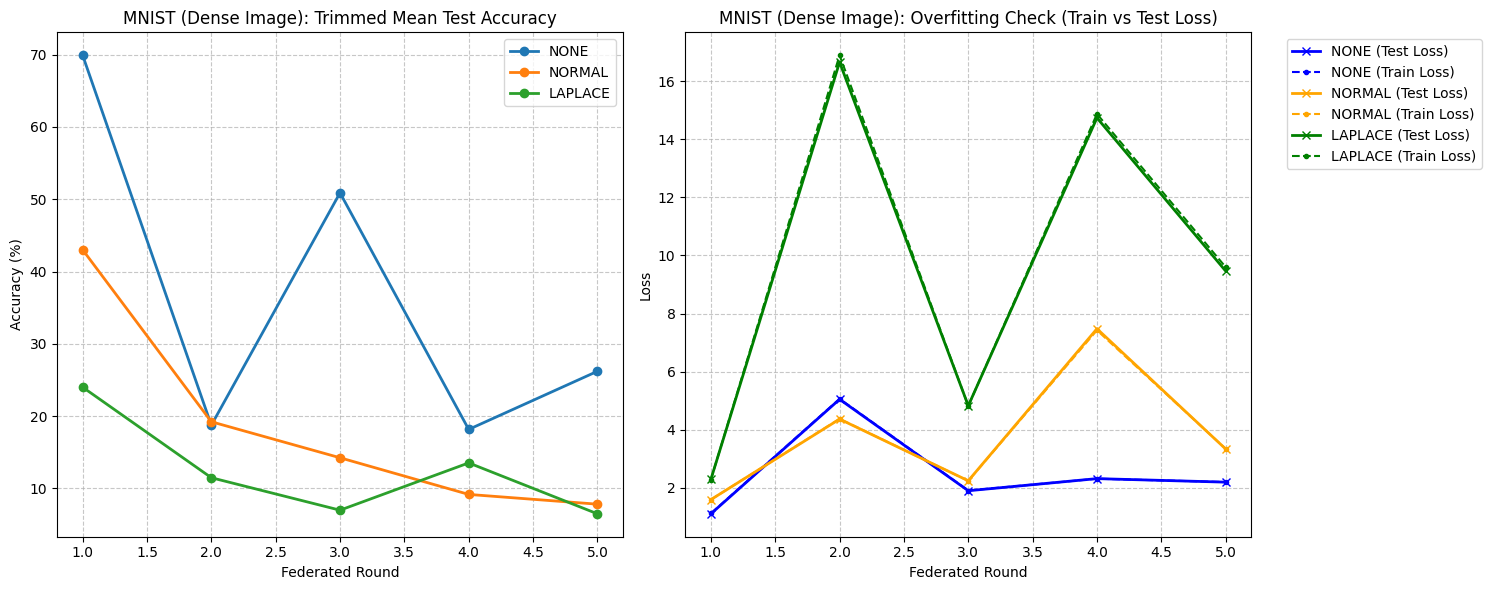

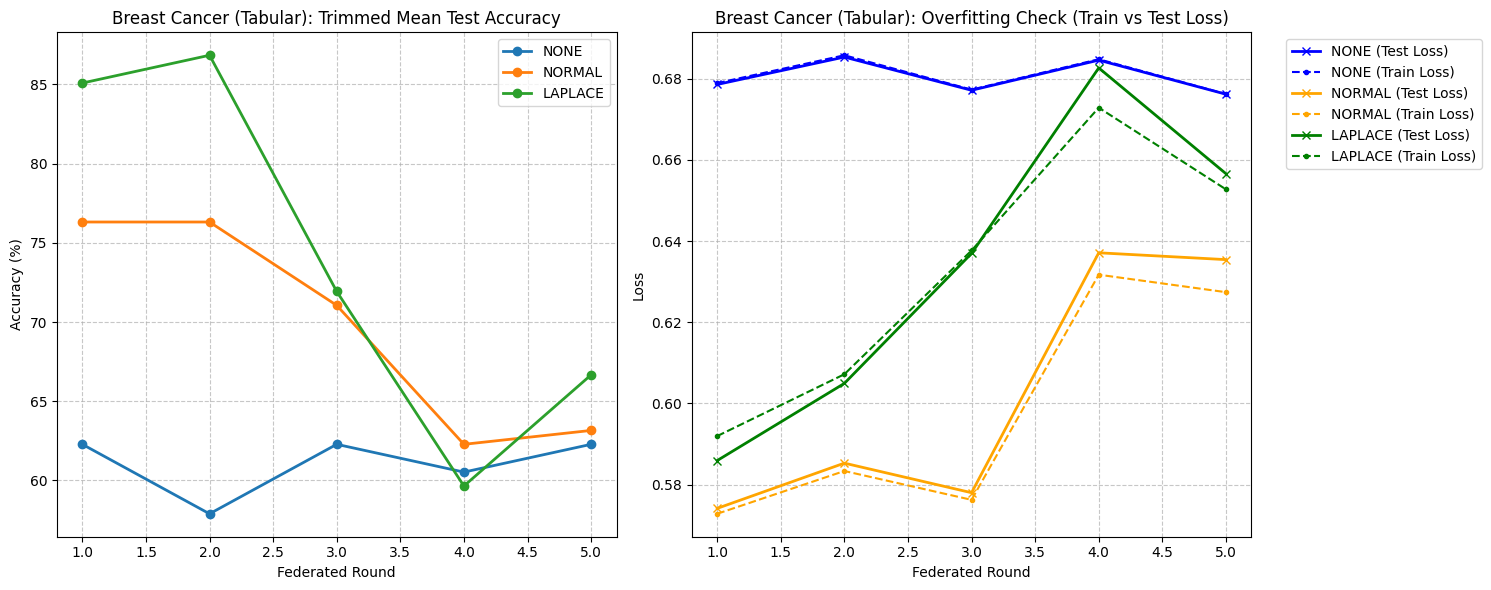

In [12]:
for dataset in datasets_to_test:
    dataset_name = "MNIST (Dense Image)" if dataset == 'mnist' else "Breast Cancer (Tabular)"

    plt.figure(figsize=(15, 6))

    # --- Subplot 1: Test Accuracy ---
    plt.subplot(1, 2, 1)
    for noise in noise_types_to_test:
        plt.plot(range(1, federated_rounds + 1), history[dataset][noise]['test_acc'],
                 marker='o', linewidth=2, label=f"{noise.upper()}")
    plt.title(f'{dataset_name}: Trimmed Mean Test Accuracy')
    plt.xlabel('Federated Round')
    plt.ylabel('Accuracy (%)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    # --- Subplot 2: Train vs Test Loss (Overfitting Check) ---
    plt.subplot(1, 2, 2)
    colors = {'none': 'blue', 'normal': 'orange', 'laplace': 'green'}

    for noise in noise_types_to_test:
        c = colors[noise]
        # Plot Test Loss (Solid Line)
        plt.plot(range(1, federated_rounds + 1), history[dataset][noise]['test_loss'],
                 marker='x', linestyle='-', linewidth=2, color=c, label=f"{noise.upper()} (Test Loss)")
        # Plot Train Loss (Dashed Line)
        plt.plot(range(1, federated_rounds + 1), history[dataset][noise]['train_loss'],
                 marker='.', linestyle='--', linewidth=1.5, color=c, label=f"{noise.upper()} (Train Loss)")

    plt.title(f'{dataset_name}: Overfitting Check (Train vs Test Loss)')
    plt.xlabel('Federated Round')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Move legend outside the plot so it doesn't cover the lines
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()


## Empirical Conclusion: Gradient Explosion and Hyper-Sensitivity

The SCAFFOLD experiment resulted in a complete mathematical breakdown, highlighting the extreme hyper-parameter sensitivity of Control Variate architectures.

**1. Compounding Variance and Exploding Gradients**
Across both modalities and all noise types, the accuracy crashed (MNIST ranging from 6% to 26%, Tabular stagnating at ~60%). Looking at the loss metrics, we observe immediate Gradient Explosion—with test losses skyrocketing to 5.0, 7.4, and even 16.6.

**2. The Incompatibility of Dual Modifications**
SCAFFOLD works by heavily modifying the gradient vector to push it toward a theoretical center. However, when the server simultaneously injects statistical noise, the global control variate becomes corrupted. The clients then attempt to correct their gradients based on a noisy target, essentially amplifying the error exponentially with every step.

**Takeaway:** SCAFFOLD is fundamentally incompatible with standard statistical noise injection out-of-the-box. The combination of control variate adjustments and randomized weight perturbations causes rapid gradient explosion. Utilizing SCAFFOLD in secure environments requires severely decayed learning rates or isolated noise protocols.